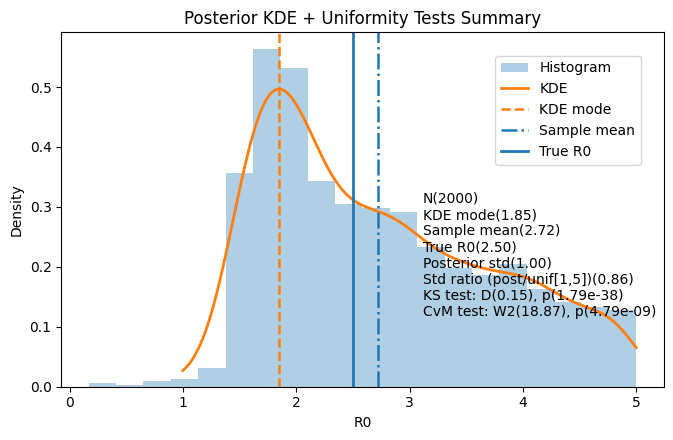

In [23]:
# the combination of summary stats v6: {6, 7, 11, 12}   
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R02p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 5.0          # prior bounds for uniform comparison
r0_true = 2.5             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6//posterior_kde_summary_R0_R02p5.png", dpi=300, bbox_inches="tight")
plt.show()

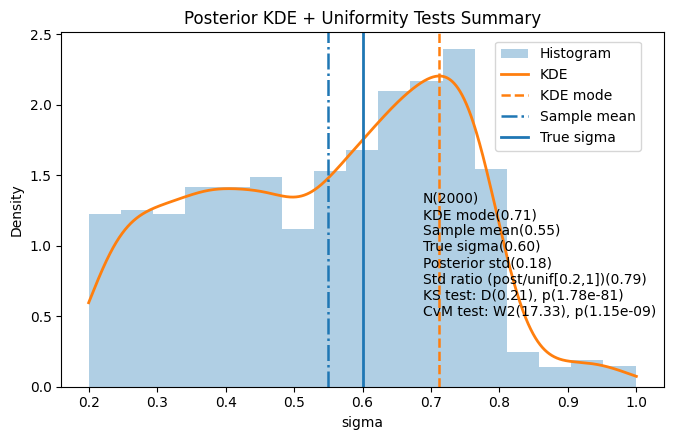

In [24]:
# Posterior distributions of sigma
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.2, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_sigma_R02p5.png", dpi=300, bbox_inches="tight")
plt.show()

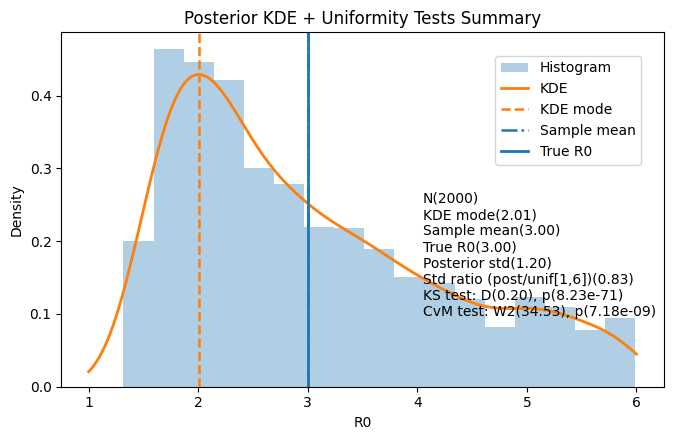

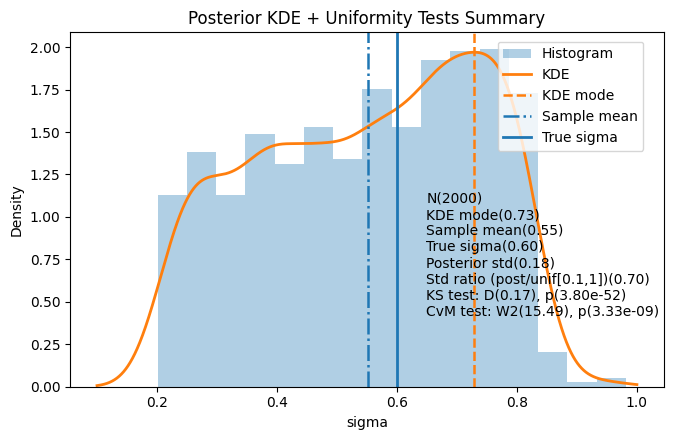

In [25]:
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R03p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 6.0          # prior bounds for uniform comparison
r0_true = 3.0             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_R0_R03p0.png", dpi=300, bbox_inches="tight")
plt.show()



# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.1, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_sigma_R03p0.png", dpi=300, bbox_inches="tight")
plt.show()

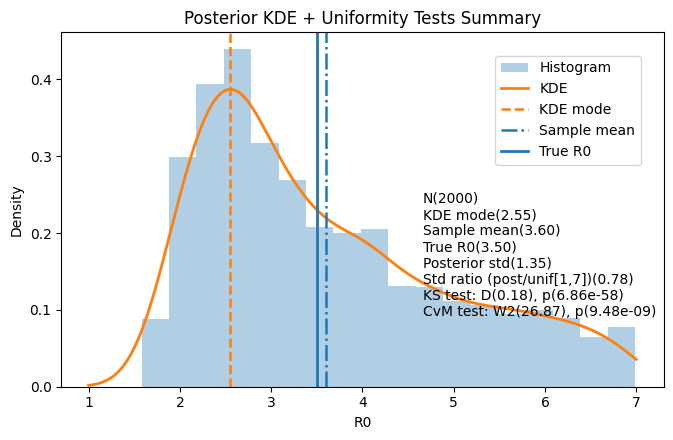

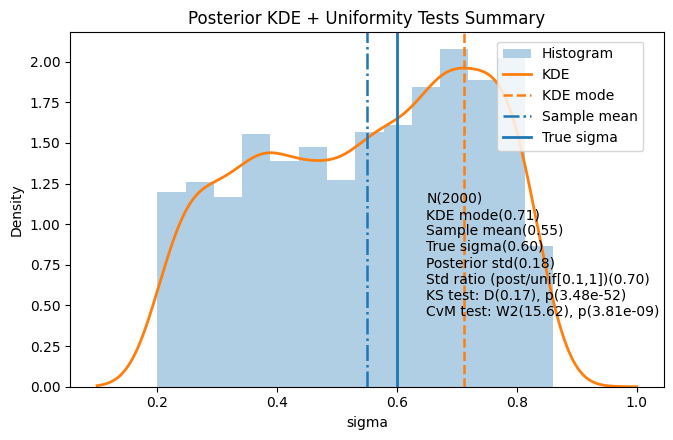

In [26]:
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R03p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 7.0          # prior bounds for uniform comparison
r0_true = 3.5             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_R0_R03p5.png", dpi=300, bbox_inches="tight")
plt.show()



# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.1, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_sigma_R03p5.png", dpi=300, bbox_inches="tight")
plt.show()

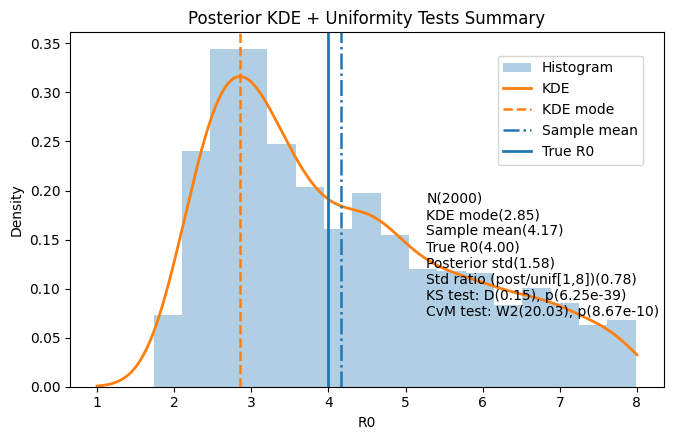

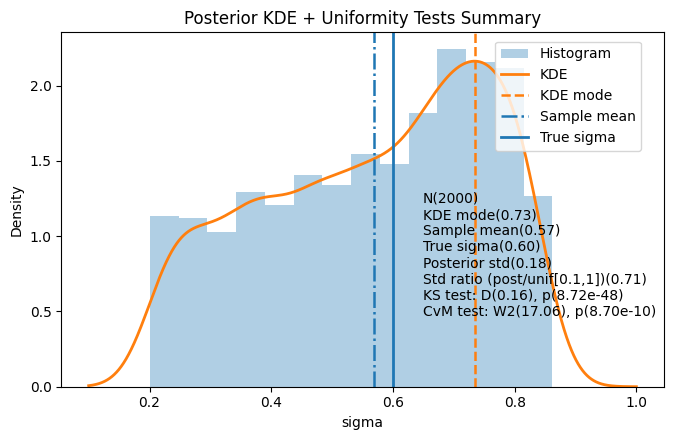

In [27]:
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R04p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 8.0          # prior bounds for uniform comparison
r0_true = 4.0             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_R0_R04p0.png", dpi=300, bbox_inches="tight")
plt.show()



# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.1, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_sigma_R04p0.png", dpi=300, bbox_inches="tight")
plt.show()

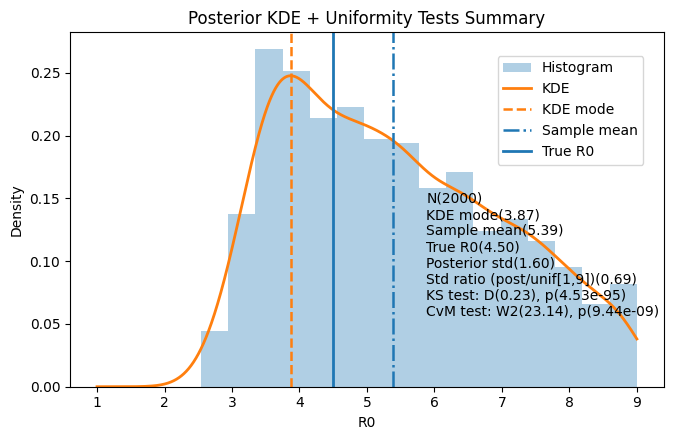

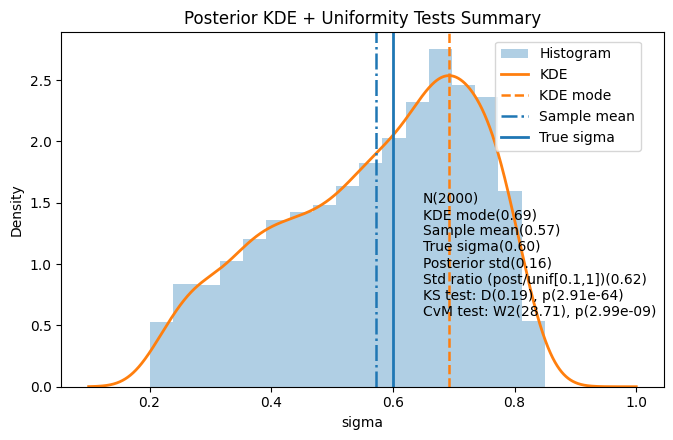

In [28]:
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R04p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 9.0          # prior bounds for uniform comparison
r0_true = 4.5             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_R0_R04p5.png", dpi=300, bbox_inches="tight")
plt.show()



# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.1, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p6/posterior_kde_summary_sigma_R04p5.png", dpi=300, bbox_inches="tight")
plt.show()

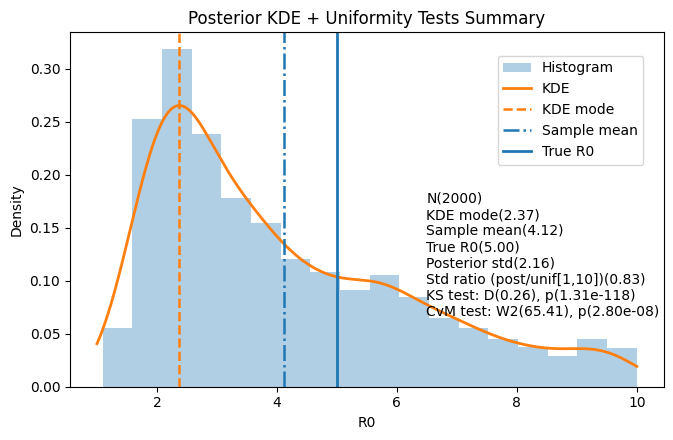

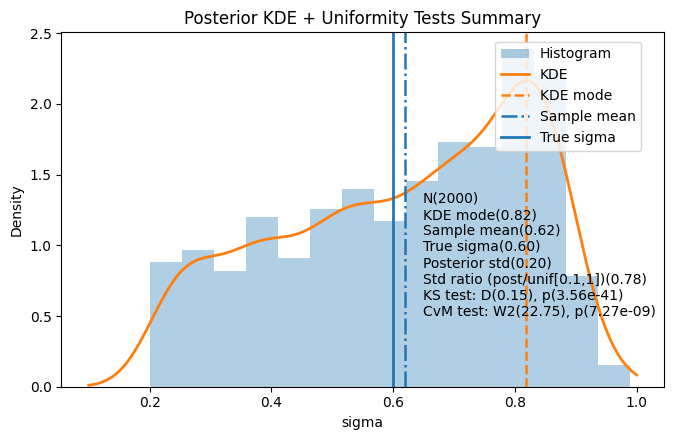

In [7]:
# Posterior distributions of R0
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, kstest, cramervonmises

# ---------- Load ----------
R0_samps = np.loadtxt("../../experimental_data/from_260312/R0_samps_2params_R05p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(R0_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 1.0, 10.0          # prior bounds for uniform comparison
r0_true = 5.0             # reference/true R0

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(r0_true, linestyle="-", lw=2.0, label="True R0")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True R0({r0_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.78), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("R0")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p8/posterior_kde_summary_R0_R05p0.png", dpi=300, bbox_inches="tight")
plt.show()



# ---------- Load ----------
sigma_samps = np.loadtxt("../../experimental_data/from_260312/sigma_samps_2params_R05p0.csv", delimiter=",")

# ---------- Clean ----------
x = np.asarray(sigma_samps).ravel()
x = x[np.isfinite(x)]

# ---------- Settings (your prior bounds + true/reference) ----------
a, b = 0.1, 1.0          # prior bounds for uniform comparison
sigma_true = 0.6             # reference/true sigma

# ---------- Posterior stats ----------
n = x.size
mu = float(np.mean(x))
sd = float(np.std(x, ddof=1))
sd_unif = (b - a) / np.sqrt(12)
sd_ratio = sd / sd_unif

# ---------- KDE mode (search within [a,b]) ----------
kde = gaussian_kde(x)  # Scott bw
xs = np.linspace(a, b, 4000)
dens = kde(xs)
mode = float(xs[np.argmax(dens)])

# ---------- Uniformity tests vs Uniform[a,b] ----------
# Transform by the uniform CDF -> should be Uniform(0,1) if x ~ Uniform(a,b)
u = (x - a) / (b - a)
u = u[(u >= 0) & (u <= 1)]  # safety; should not drop anything if bounds are correct

ks = kstest(u, "uniform")
cvm = cramervonmises(u, "uniform")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(x, bins="fd", density=True, alpha=0.35, label="Histogram")
ax.plot(xs, dens, lw=2, label="KDE", color="C1")

# Reference lines
ax.axvline(mode, linestyle="--", lw=1.8, label="KDE mode", color="C1")
ax.axvline(mu, linestyle="-.", lw=1.8, label="Sample mean")
ax.axvline(sigma_true, linestyle="-", lw=2.0, label="True sigma")

# Text box with required info
txt = (
    f"N({n})\n"
    f"KDE mode({mode:.2f})\n"
    f"Sample mean({mu:.2f})\n"
    f"True sigma({sigma_true:.2f})\n"
    f"Posterior std({sd:.2f})\n"
    f"Std ratio (post/unif[{a:g},{b:g}])({sd_ratio:.2f})\n"
    f"KS test: D({ks.statistic:.2f}), p({ks.pvalue:.2e})\n"
    f"CvM test: W2({cvm.statistic:.2f}), p({cvm.pvalue:.2e})"
)
# ax.text(
#     0.52, 0.98, txt,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     bbox=dict(boxstyle="None", facecolor="white", alpha=0.85)
# )
ax.text(
    0.60, 0.55, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=None
)


# Put legend outside to avoid overlap with the text box
ax.legend(loc="center left", bbox_to_anchor=(0.72, 0.82), borderaxespad=0.)

ax.set_title("Posterior KDE + Uniformity Tests Summary")
ax.set_xlabel("sigma")
ax.set_ylabel("Density")
fig.tight_layout()
fig.savefig("../../figures/from_260312/posterior_results/sigma0p8/posterior_kde_summary_sigma_R05p0.png", dpi=300, bbox_inches="tight")
plt.show()